In [1]:
from tensorflow import keras
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np

In [2]:
import tensorflow as tf

In [3]:
print(tf.__version__)

2.20.0


In [4]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


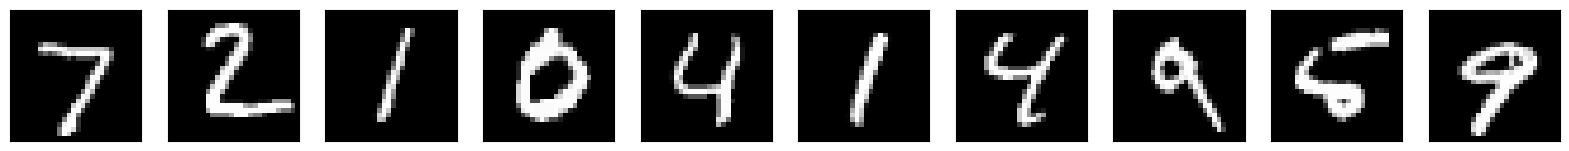

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

n = 10  # how many records we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

![image.png](attachment:7b66c461-7e86-42f8-8fa2-1cb11eaaaaa2.png)

In [7]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, UpSampling2D, Reshape

In [9]:
encode_model = Sequential()

############
# Encoding #
############

## FIRST SET OF LAYERS
# CONVOLUTIONAL LAYER
encode_model.add(Conv2D(filters=16, kernel_size=(3,3),
                 input_shape=(28, 28, 1), activation='relu', padding='same'))
# POOLING LAYER
encode_model.add(MaxPool2D(pool_size=(2, 2),  padding='same'))

## SECOND SET OF LAYERS
# CONVOLUTIONAL LAYER
encode_model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'))
# POOLING LAYER
encode_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))

## THIRD SET OF LAYERS
# CONVOLUTIONAL LAYER
#encode_model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'))
# POOLING LAYER

#encode_model.add(MaxPool2D(pool_size=(2, 2), padding='valid'))

encode_model.add(Flatten(input_shape=[7,7,8]))

encode_model.add(Dense(7*7*8,activation="relu"))
encode_model.add(Dense(30,activation="relu"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
############
# Decoding #
############
decode_model=Sequential()

# DeConv1
#decode_model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'))
# Upsampling LAYER
#decode_model.add(UpSampling2D((2, 2)))

decode_model.add(Dense(7*7*8,activation="relu"))
decode_model.add(Reshape([7,7,8]))

# DeConv2
decode_model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'))
# Upsampling LAYER
decode_model.add(UpSampling2D((2, 2)))

# Deconv3
decode_model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same'))
# POOLING LAYER
decode_model.add(UpSampling2D((2, 2)))

decode_model.add(Conv2D(1, kernel_size=(3,3), activation='sigmoid', padding='same'))


In [14]:
autoencoder = Sequential([encode_model, decode_model])

In [15]:
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
autoencoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 30)             │       167,166 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 28, 28, 1)      │        14,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,215 (707.87 KB)

 Trainable params: 181,215 (707.87 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras import models

In [18]:
autoencoder.save('Conv_autoencoder.keras')

In [19]:
encode_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 392)            │       154,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │        11,790 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,166 (652.99 KB)

 Trainable params: 167,166 (652.99 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
decode_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 392)            │        12,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,049 (54.88 KB)

 Trainable params: 14,049 (54.88 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
x_train = x_train.reshape(60000,28,28,1)
x_train = x_train/255
x_train.shape

(60000, 28, 28, 1)

In [22]:
x_test = x_test.reshape(10000, 28, 28, 1)
x_test = x_test/255
x_test.shape

(10000, 28, 28, 1)

In [23]:
# Train the model

history = autoencoder.fit(x=x_train, y=x_train,
                epochs=10,
                batch_size=128,
                shuffle=True, verbose=1,
                validation_data=(x_test, x_test),
               )

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 143ms/step - accuracy: 0.1869 - loss: 0.6948 - val_accuracy: 0.3079 - val_loss: 0.6939
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 139ms/step - accuracy: 0.4790 - loss: 0.6931 - val_accuracy: 0.6353 - val_loss: 0.6923
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step - accuracy: 0.7308 - loss: 0.6914 - val_accuracy: 0.7835 - val_loss: 0.6907
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 140ms/step - accuracy: 0.7998 - loss: 0.6899 - val_accuracy: 0.8050 - val_loss: 0.6891
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 142ms/step - accuracy: 0.8079 - loss: 0.6881 - val_accuracy: 0.8070 - val_loss: 0.6872
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 143ms/step - accuracy: 0.8087 - loss: 0.6860 - val_accuracy: 0.8072 - val_loss: 0.6847
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - accuracy: 0.8088 - loss: 0.6832 - val_accuracy: 0.8072 - val_loss: 0.6816
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - accuracy: 0.8088 - loss: 0

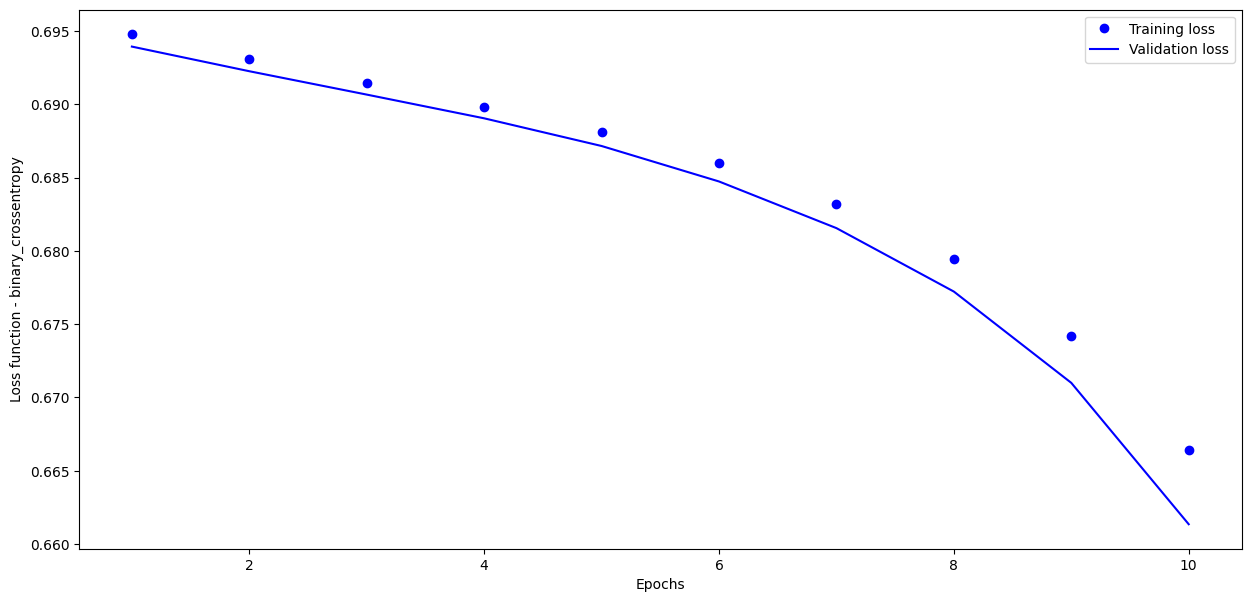

In [27]:
losses = history.history['loss']
losses_val = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

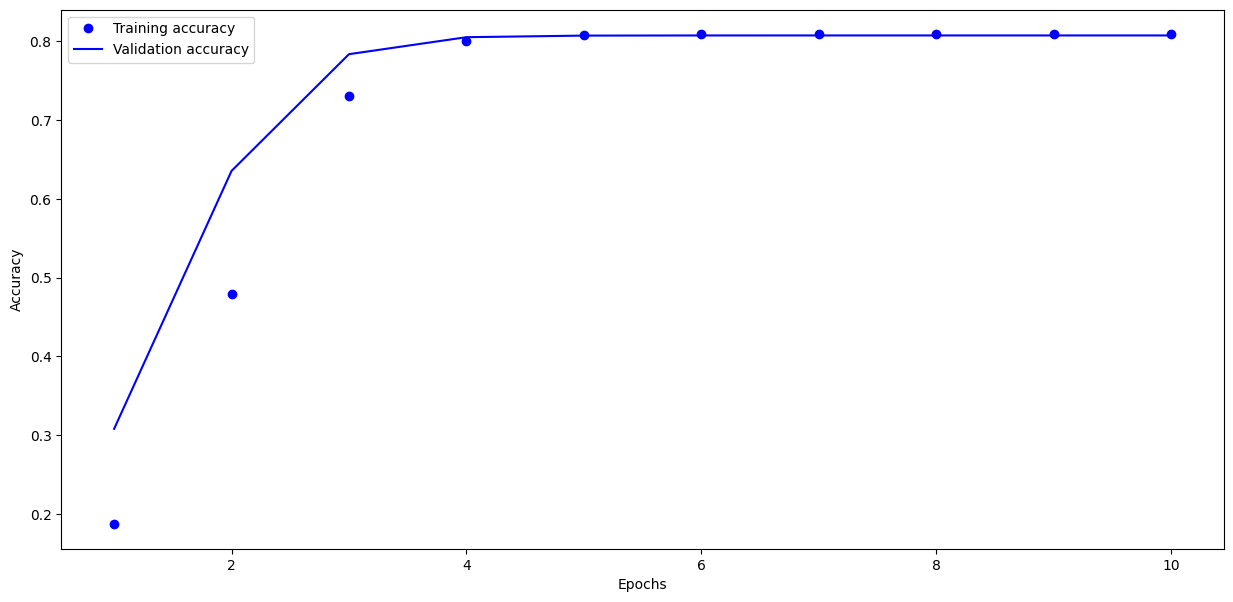

In [24]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


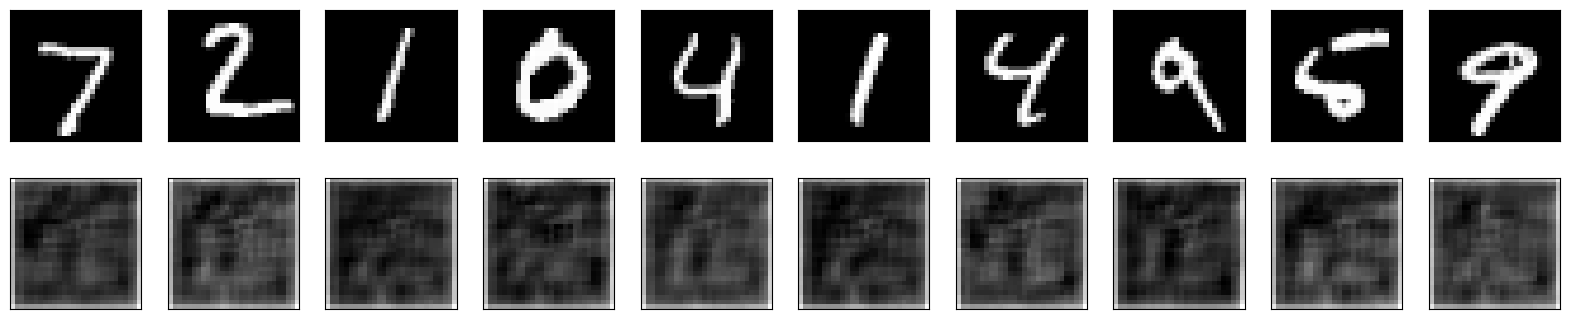

In [25]:
decoded_imgs = autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [26]:
#

![image.png](attachment:f51e6fad-c8b0-48ee-b841-08b51142fe9c.png)

## Lab Logbook requirement:

1) Copy the autoencoder model and train it with epochs=Z+40,
where your SID is: XXXXXXZ

Use "adam" optimaser.

Leave other parameters the same as in Task 2.

3) Please only add to your Lab Logbook print-screens of:
- Table of your model autoencoder.summary()
- Code of your autoencoder.fit()
- Accuracy detailed graph
- Document the plot of the decoded images for task 2. Change the colour, appearance, and shape of the plot according to your own choice (see plt.figure() parameters).


NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.

In [28]:
# Load the trained convolutional autoencoder model
autoencoder_2 = models.load_model('Conv_autoencoder.keras')

# Compile the model using Adam optimizer and same loss as before
autoencoder_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adadelta', because it has 34 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [31]:
%whos

Variable             Type               Data/Info
-------------------------------------------------
Conv2D               type               <class 'keras.src.layers.<...>olutional.conv2d.Conv2D'>
Dense                type               <class 'keras.src.layers.core.dense.Dense'>
Flatten              type               <class 'keras.src.layers.<...>shaping.flatten.Flatten'>
Input                function           <function Input at 0x7e343ef7bc40>
MaxPool2D            type               <class 'keras.src.layers.<...>_pooling2d.MaxPooling2D'>
Model                type               <class 'keras.src.models.model.Model'>
Reshape              type               <class 'keras.src.layers.<...>shaping.reshape.Reshape'>
Sequential           type               <class 'keras.src.models.sequential.Sequential'>
UpSampling2D         type               <class 'keras.src.layers.<...>sampling2d.UpSampling2D'>
Z                    int                1
accuracy_array       list               n=10
autoen

In [33]:
# Train the autoencoder with SID-based epochs (Z+40)
Z = 1
my_epochs = Z + 40

x_train_fast = x_train[:10000]

history_2 = autoencoder_2.fit(
    x_train_fast,
    x_train_fast,
    epochs=my_epochs,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/41
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 314ms/step - accuracy: 0.8003 - loss: 0.1600 - val_accuracy: 0.8020 - val_loss: 0.1568
Epoch 2/41
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 302ms/step - accuracy: 0.8023 - loss: 0.1519 - val_accuracy: 0.8008 - val_loss: 0.1503
Epoch 3/41
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 346ms/step - accuracy: 0.8035 - loss: 0.1463 - val_accuracy: 0.8041 - val_loss: 0.1458
Epoch 4/41
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 273ms/step - accuracy: 0.8043 - loss: 0.1420 - val_accuracy: 0.8039 - val_loss: 0.1412
Epoch 5/41
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.8050 - loss: 0.1385 - val_accuracy: 0.8047 - val_loss: 0.1379
Epoch 6/41
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.8056 - loss: 0.1352 - val_accuracy: 0.8064 - val_loss: 0.1372
Epoch 7/41
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 305ms/step - accuracy: 0.8063 - loss: 0.1320 - val_accuracy: 0.8062 - val_loss: 0.1324
Epoch 8/41
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 302ms/step - accuracy: 0.8068 - loss: 0.1292 - val_accu

In [34]:
# Print autoencoder model summary for logbook
autoencoder_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 30)             │       167,166 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 28, 28, 1)      │        14,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,647 (2.07 MB)

 Trainable params: 181,215 (707.87 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 362,432 (1.38 MB)

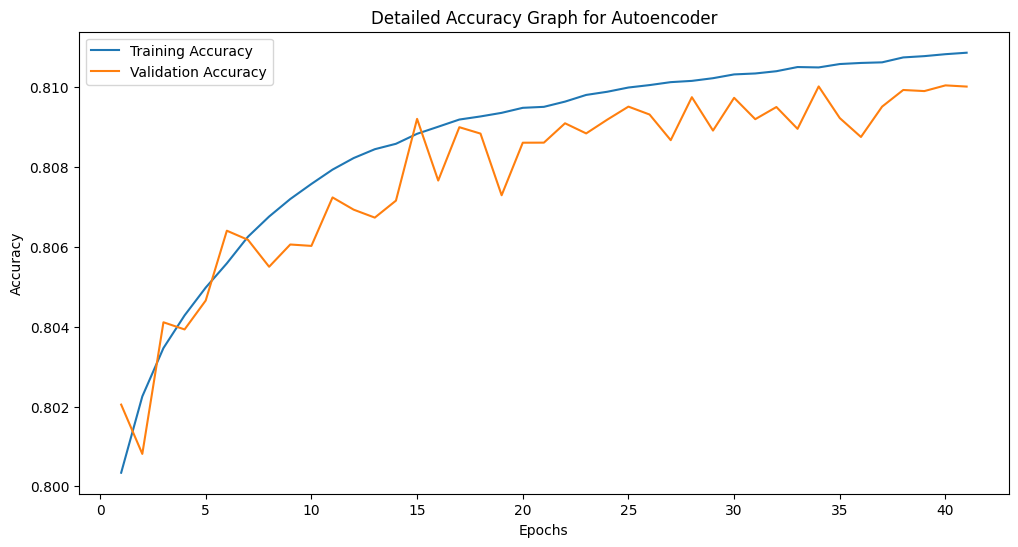

In [35]:
# Plot detailed accuracy graph for autoencoder training
history_dict = history_2.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,6))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Detailed Accuracy Graph for Autoencoder')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


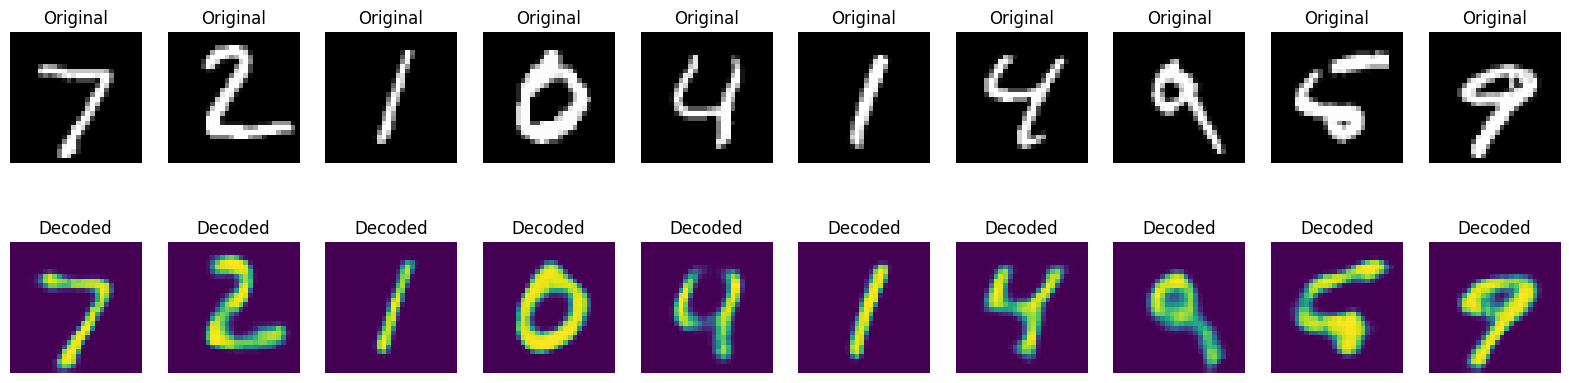

In [38]:
# Display original vs reconstructed images from autoencoder
decoded_imgs = autoencoder_2.predict(x_test)

n = 10  # number of images
plt.figure(figsize=(20, 5))

for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='viridis')  # changed colour style
    plt.title("Decoded")
    plt.axis('off')

plt.show()